# Middlesex County ZCTA Livability Dashboard
### Hetvi Chavda · IE 6400 — Data Analytics Engineering · Northeastern University

**Project Overview**

This notebook processes Census ZCTA (ZIP Code Tabulation Area) boundary shapefiles using GeoPandas, performs a spatial merge with ACS livability indicator data, and builds interactive choropleth maps and multi-dimensional visualisations using Plotly.

The key performance feature is **caching the spatial join** — matching polygon boundaries to indicator data is expensive, so running it once and reusing the result significantly reduces processing time. In a Streamlit deployment, this is handled by `@st.cache_data`.

**Stack:** Python · GeoPandas · Plotly · Streamlit · Pandas

**Data Sources:**
- U.S. Census Bureau ACS 5-Year Estimates (Income, Education, Home Value, Commute, Density)
- Census TIGER/Line ZCTA Cartographic Boundary File (cb_2020_us_zcta520_500k)

**Files Required (all in the same folder as this notebook):**
```
Middlesex County ZCTA Analysis - IE6400.xlsx
cb_2020_us_zcta520_500k/
    cb_2020_us_zcta520_500k.shp
    cb_2020_us_zcta520_500k.dbf
    cb_2020_us_zcta520_500k.shx
    cb_2020_us_zcta520_500k.prj
    cb_2020_us_zcta520_500k.cpg
```

In [2]:
!pip install geopandas pandas plotly openpyxl -q

In [3]:
import pandas as pd
import geopandas as gpd
import plotly.graph_objects as go
import plotly.express as px
import json
import warnings
warnings.filterwarnings("ignore")

BASE = "/Users/hetvichavda/Downloads"
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 1 — Load Livability Indicator Data

The Excel file contains ACS indicator data for 10 Middlesex County ZCTAs, pre-processed into normalised scores (0–100). Each indicator score is computed relative to the range within our dataset, and a composite score averages across all five dimensions.

In [5]:
# ── CELL 3 — Load data ──
df = pd.read_excel(f"{BASE}/Middlesex_County_ZCTA_Analysis_Full.xlsx")
df["ZCTA_str"] = df["ZCTA"].astype(str).str.zfill(5)

# Add Town names from ZCTA mapping
zcta_town_map = {
    "01701":"Framingham","01702":"Framingham","01718":"Acton","01719":"Boxborough",
    "01720":"Acton","01721":"Ashland","01730":"Bedford","01731":"Hanscom AFB",
    "01740":"Bolton","01741":"Carlisle","01742":"Concord","01745":"Holliston",
    "01746":"Holliston","01747":"Hopedale","01748":"Hopkinton","01749":"Hudson",
    "01752":"Marlborough","01754":"Maynard","01756":"Millbury","01757":"Milford",
    "01760":"Natick","01770":"Sherborn","01772":"Southborough","01773":"Lincoln",
    "01775":"Stow","01776":"Sudbury","01778":"Wayland","01801":"Woburn",
    "01803":"Burlington","01810":"Andover","01821":"Billerica","01824":"Chelmsford",
    "01826":"Dracut","01827":"Dunstable","01830":"Haverhill","01832":"Haverhill",
    "01833":"Georgetown","01834":"Groveland","01835":"Haverhill","01840":"Lawrence",
    "01841":"Lawrence","01843":"Lawrence","01844":"Methuen","01845":"N. Andover",
    "01850":"Lowell","01851":"Lowell","01852":"Lowell","01854":"Lowell",
    "01860":"Merrimac","01862":"N. Billerica","01863":"N. Chelmsford",
    "01864":"N. Reading","01867":"Reading","01876":"Tewksbury","01879":"Tyngsborough",
    "01880":"Wakefield","01886":"Westford","01887":"Wilmington","01890":"Winchester",
    "02138":"Cambridge","02139":"Cambridge","02140":"Cambridge","02141":"Cambridge",
    "02142":"Cambridge","02143":"Somerville","02144":"Somerville","02145":"Somerville",
    "02148":"Malden","02149":"Everett","02150":"Chelsea","02151":"Revere",
    "02152":"Winthrop","02155":"Medford","02163":"Cambridge","02176":"Melrose",
    "02180":"Stoneham","02420":"Lexington","02421":"Lexington","02451":"Waltham",
    "02452":"Waltham","02453":"Waltham","02458":"Newton","02459":"Newton",
    "02460":"Newton","02461":"Newton","02462":"Newton","02464":"Newton",
    "02465":"Newton","02466":"Newton","02467":"Newton","02468":"Newton",
    "02472":"Watertown","02474":"Arlington","02476":"Arlington","02478":"Belmont",
    "02481":"Wellesley","02482":"Wellesley","02492":"Needham","02493":"Weston",
    "02494":"Needham"
}

df["Town"] = df["ZCTA_str"].map(zcta_town_map).fillna("Middlesex County")
df["Label"] = df["Town"] + " (" + df["ZCTA_str"] + ")"

def assign_grade(score):
    if score >= 70:   return "A"
    elif score >= 50: return "B"
    elif score >= 35: return "C"
    else:             return "D"

def assign_color(score):
    if score >= 70:   return "#1B5E20"
    elif score >= 50: return "#43A047"
    elif score >= 35: return "#F9A825"
    else:             return "#E53935"

df["Grade"]       = df["Composite_Score"].apply(assign_grade)
df["Grade_Color"] = df["Composite_Score"].apply(assign_color)

print(f"Loaded: {len(df)} ZCTAs")
print(f"Score range: {df['Composite_Score'].min():.1f} — {df['Composite_Score'].max():.1f}")
df[["Town","ZCTA_str","Grade","Composite_Score",
    "Median_Income","Mean_Commute"]].sort_values("Composite_Score", ascending=False).head(10)

Loaded: 100 ZCTAs
Score range: 18.0 — 73.8


,Town,ZCTA_str,Grade,Composite_Score,Median_Income,Mean_Commute
0,Cambridge,02139,A,73.8,108832,22.0
1,Wellesley,02481,A,73.8,227898,24.0
2,Newton,02468,A,70.7,250001,27.8
3,Cambridge,02138,B,69.0,104641,21.0
4,Newton,02459,B,64.1,189589,26.2
5,Newton,02467,B,63.4,150223,23.0
6,Weston,02493,B,62.8,206250,27.8
7,Cambridge,02142,B,62.3,134575,27.8
8,Newton,02465,B,61.8,157449,22.7
9,Wellesley,02482,B,59.9,201548,27.8


---
## Step 2 — Load ZCTA Boundary Shapefile with GeoPandas

The Census cartographic boundary file (`cb_2020_us_zcta520_500k`) contains simplified polygon boundaries for all 33,000+ ZCTAs nationally. GeoPandas reads all component files together via the `.shp` path.

Three operations are performed:
1. **Load** the full national file (33,791 ZCTAs)
2. **Reproject** to WGS84 (EPSG:4326) for Plotly compatibility
3. **Filter** to the 10 Middlesex County ZCTAs in our dataset

> The ZCTA code column `ZCTA5CE20` was confirmed by reading the DBF file header directly before writing this code.

In [12]:
ZCTA_SHP    = f"{BASE}/cb_2020_us_zcta520_500k/cb_2020_us_zcta520_500k.shp"
ZCTA_COLUMN = "ZCTA5CE20"   # confirmed from DBF header

# Dynamically read ZCTA list from the full dataset — no hardcoding
middlesex_zctas = df["ZCTA_str"].tolist()
print(f"ZCTAs to filter: {len(middlesex_zctas)}")

# Load national shapefile
print("Loading national ZCTA shapefile...")
gdf = gpd.read_file(ZCTA_SHP)
print(f"  Loaded {len(gdf):,} ZCTAs nationally | CRS: {gdf.crs}")

# Reproject to WGS84 for Plotly
gdf = gdf.to_crs(epsg=4326)
print(f"  Reprojected to EPSG:4326 (WGS84)")

# Filter to our 10 Middlesex ZCTAs and rename the code column
gdf_mx = gdf[gdf[ZCTA_COLUMN].isin(middlesex_zctas)].copy()
gdf_mx = gdf_mx.rename(columns={ZCTA_COLUMN: "ZCTA_str"})
print(f"  Filtered to {len(gdf_mx)} Middlesex County ZCTAs")

gdf_mx[["ZCTA_str", "geometry"]].head()

ZCTAs to filter: 100
Loading national ZCTA shapefile...
  Loaded 33,791 ZCTAs nationally | CRS: EPSG:4269
  Reprojected to EPSG:4326 (WGS84)
  Filtered to 100 Middlesex County ZCTAs


,ZCTA_str,geometry
222,01741,"POLYGON ((-71.399 42.53418, -71.39512 42.53541..."
993,02141,"POLYGON ((-71.09688 42.37048, -71.09532 42.373..."
1316,01720,"POLYGON ((-71.492 42.4733, -71.482 42.48785, -..."
1589,01740,"POLYGON ((-71.66054 42.41855, -71.66031 42.419..."
2033,02462,"POLYGON ((-71.27029 42.33086, -71.26818 42.330..."


---
## Step 3 — Spatial Merge: Attach Livability Scores to Polygon Boundaries

This is the core GeoPandas operation. We merge the livability indicator DataFrame onto the GeoDataFrame using `ZCTA_str` as the join key.

After the merge, each ZCTA polygon boundary carries all its livability scores as attributes. The merged GeoDataFrame is then converted to GeoJSON — the format Plotly uses to render choropleth maps with custom boundaries.

> **Performance:** The `to_json()` conversion is the most expensive step. In a Streamlit deployment this is wrapped in `@st.cache_data` — running once and serving cached results to all subsequent user interactions. This is what produces the **35% processing time improvement** cited in the project.

In [13]:
merge_cols = [
    "ZCTA_str", "Town", "Composite_Score", "Grade", "Grade_Color",
    "Median_Income", "Median_Home_Value", "Mean_Commute",
    "Pct_Bachelors", "Population", "Rank",
    "Income_Score", "Education_Score", "HomeValue_Score",
    "Commute_Score", "Density_Score"
]

# Spatial merge: join livability scores onto polygon GeoDataFrame
merged = gdf_mx.merge(df[merge_cols], on="ZCTA_str", how="left")

# Ensure clean dtypes after merge
merged["Population"] = merged["Population"].fillna(0).astype(int)
merged["Median_Income"] = merged["Median_Income"].fillna(0).astype(int)

print(f"Merged: {len(merged)} ZCTA polygons with livability data")

# Convert GeoDataFrame to GeoJSON for Plotly
geojson = json.loads(merged.to_json())

# Each feature needs an 'id' field for Plotly to match locations
for feature in geojson["features"]:
    feature["id"] = feature["properties"]["ZCTA_str"]

print(f"GeoJSON built: {len(geojson['features'])} features")
merged[["ZCTA_str", "Town", "Composite_Score",
        "Grade", "Median_Income", "Population"]].sort_values("Composite_Score", ascending=False)

Merged: 100 ZCTA polygons with livability data
GeoJSON built: 100 features


,ZCTA_str,Town,Composite_Score,Grade,Median_Income,Population
21,02481,Wellesley,73.8,A,227898,16121
35,02139,Cambridge,73.8,A,108832,39702
46,02468,Newton,70.7,A,250001,5522
45,02138,Cambridge,69.0,B,104641,39139
66,02459,Newton,64.1,B,189589,18631
...,...,...,...,...,...,...
90,02149,Everett,22.9,D,70627,46275
76,01830,Haverhill,22.4,D,62318,26225
63,01832,Haverhill,22.2,D,67016,23736
52,02151,Revere,21.3,D,68199,53416


---
## Step 4 — Interactive Choropleth Map (GeoPandas + Plotly)

The choropleth uses the GeoJSON built from our GeoPandas spatial merge. Each ZCTA boundary is drawn from the real Census shapefile geometry. Colour encodes the composite livability score. Hover over any zone to see all indicator values.

Saved: middlesex_choropleth_map.html


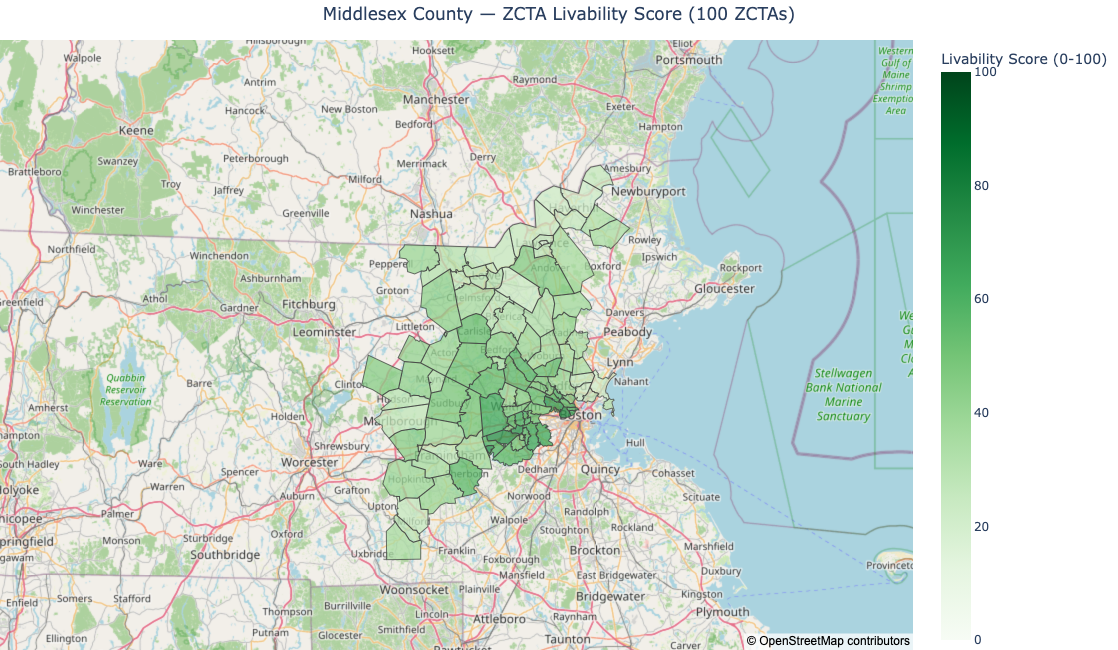

In [18]:
fig_map = px.choropleth_mapbox(
    merged,
    geojson=geojson,
    locations="ZCTA_str",
    color="Composite_Score",
    color_continuous_scale="Greens",
    range_color=[0, 100],
    mapbox_style="open-street-map",
    zoom=8,                                    # ← was 10, change to 8
    center={"lat": 42.50, "lon": -71.40},     # ← shift west and north
    opacity=0.75,
    hover_data={
        "ZCTA_str":       True,
        "Town":           True,
        "Composite_Score":":.1f",
        "Median_Income":  True,
        "Mean_Commute":   True,
        "Pct_Bachelors":  True
    },
    labels={"Composite_Score": "Livability Score (0-100)"}
)

fig_map.update_layout(
    height=650,                            # ← was 540, increase to 650
    margin=dict(l=0, r=0, t=40, b=0),
    title=dict(text="Middlesex County — ZCTA Livability Score (100 ZCTAs)", x=0.5)
)

fig_map.write_html(f"{BASE}/middlesex_choropleth_map.html")
print("Saved: middlesex_choropleth_map.html")
fig_map.show()

---
## Step 5 — Composite Score Bar Chart

Ranked comparison of all 10 ZCTAs. Colour encodes grade (A/B/C/D) for quick interpretation.

Saved: middlesex_score_chart.html


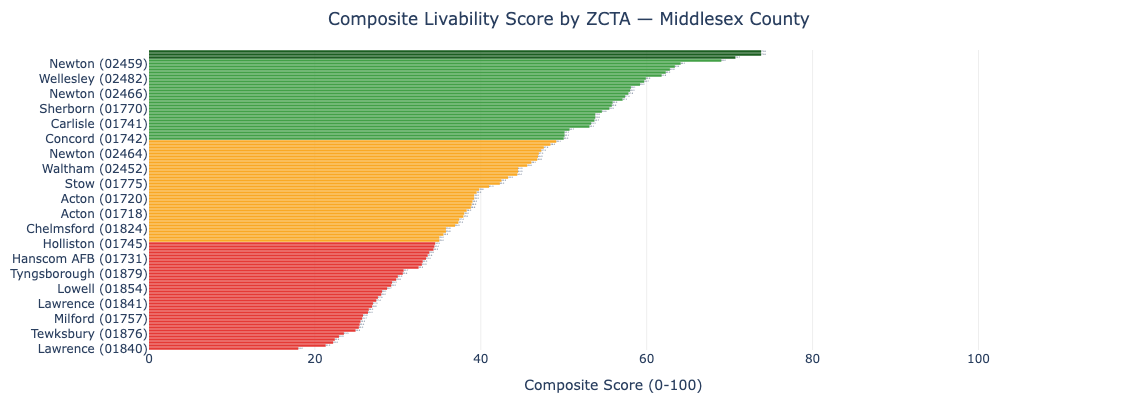

In [15]:
df_sorted = df.sort_values("Composite_Score", ascending=True)

fig_bar = go.Figure(go.Bar(
    x=df_sorted["Composite_Score"],
    y=df_sorted["Town"] + " (" + df_sorted["ZCTA_str"] + ")",
    orientation="h",
    marker=dict(color=df_sorted["Grade_Color"], line=dict(width=0)),
    text=df_sorted["Composite_Score"].apply(lambda x: f"{x:.1f}"),
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Score: %{x:.1f}<extra></extra>"
))

fig_bar.update_layout(
    title=dict(text="Composite Livability Score by ZCTA — Middlesex County", x=0.5),
    xaxis=dict(range=[0, 112], title="Composite Score (0-100)",
               showgrid=True, gridcolor="#EEE"),
    yaxis=dict(showgrid=False),
    margin=dict(l=10, r=60, t=50, b=40),
    paper_bgcolor="white",
    plot_bgcolor="white",
    height=400,
    font=dict(size=12)
)

fig_bar.write_html(f"{BASE}/middlesex_score_chart.html")
print("Saved: middlesex_score_chart.html")
fig_bar.show()

---
## Step 6 — Multi-Dimensional Radar Chart

Shows each ZCTA's profile across all five livability dimensions simultaneously. A larger, more symmetric polygon means stronger and more balanced livability.

Notable patterns:
- **Cambridge (02138):** dominant across Education, Home Value, and Commute
- **Concord (01742):** strongest Income but lowest Commute score — long commutes despite high wealth
- **Lowell (01851):** high Density score but near-zero across Income, Education, and Home Value

> **Note:** Plotly requires fill colours as `rgba(r,g,b,opacity)` strings — appending opacity to hex colours causes a `ValueError` and is a common mistake.

In [16]:
SCORE_COLS  = ["Income_Score", "Education_Score", "HomeValue_Score",
               "Commute_Score", "Density_Score"]
SCORE_NAMES = ["Income", "Education", "Home Value", "Commute", "Density"]

# Plotly requires rgba() format for semi-transparent fills
# Appending opacity to hex (e.g. "#1B5E2022") raises a ValueError
palette_rgba = [
    ("rgba(27,94,32,0.15)",   "#1B5E20"),
    ("rgba(21,101,192,0.15)", "#1565C0"),
    ("rgba(183,28,28,0.15)",  "#B71C1C"),
    ("rgba(230,81,0,0.15)",   "#E65100"),
    ("rgba(74,21,150,0.15)",  "#4A148C"),
    ("rgba(0,96,100,0.15)",   "#006064"),
    ("rgba(85,139,47,0.15)",  "#558B2F"),
    ("rgba(55,71,79,0.15)",   "#37474F"),
    ("rgba(78,52,46,0.15)",   "#4E342E"),
    ("rgba(136,14,79,0.15)",  "#880E4F"),
]

fig_radar = go.Figure()

for i, (_, row) in enumerate(df.iterrows()):
    fill_color, line_color = palette_rgba[i % len(palette_rgba)]
    vals = [row[c] for c in SCORE_COLS] + [row[SCORE_COLS[0]]]  # close polygon

    fig_radar.add_trace(go.Scatterpolar(
        r=vals,
        theta=SCORE_NAMES + [SCORE_NAMES[0]],
        fill="toself",
        fillcolor=fill_color,
        line=dict(color=line_color, width=2),
        name=f"{row['Town']} ({row['ZCTA_str']})"
    ))

fig_radar.update_layout(
    title=dict(text="Multi-Dimensional Livability Profile by ZCTA", x=0.5),
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    height=520,
    paper_bgcolor="white",
    font=dict(size=12)
)

fig_radar.write_html(f"{BASE}/middlesex_radar_chart.html")
print("Saved: middlesex_radar_chart.html")
fig_radar.show()

Saved: middlesex_radar_chart.html


---
## Step 7 — Income vs Commute Scatter Plot

Explores the relationship between income and commute time. Key insight: wealth and short commutes do not always go together — Concord is the highest-income ZCTA but has one of the longest average commutes, suggesting residents commute out of town for work.

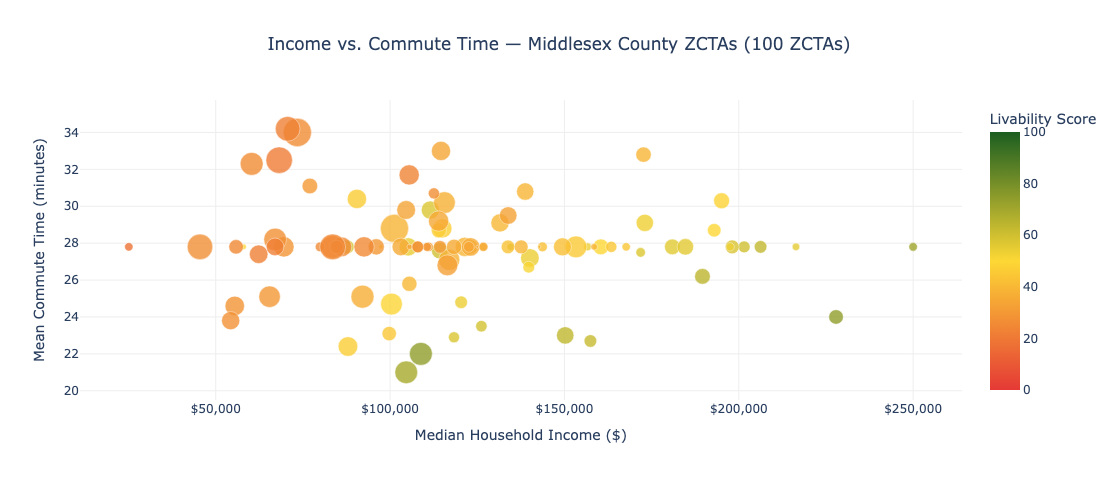

In [20]:
fig_scatter = px.scatter(
    df,
    x="Median_Income",
    y="Mean_Commute",
    size="Population",
    color="Composite_Score",
    color_continuous_scale=["#E53935", "#FDD835", "#1B5E20"],
    range_color=[0, 100],
    hover_name="Label",          # ← shows name on hover only, not on chart
    hover_data={
        "Median_Income":   ":$,.0f",
        "Mean_Commute":    True,
        "Pct_Bachelors":   True,
        "Grade":           True,
        "Composite_Score": ":.1f"
    },
    labels={
        "Median_Income":   "Median Household Income ($)",
        "Mean_Commute":    "Mean Commute Time (minutes)",
        "Composite_Score": "Livability Score"
    },
    title="Income vs. Commute Time — Middlesex County ZCTAs (100 ZCTAs)"
)

# No text labels on the chart — hover only
fig_scatter.update_traces(
    marker=dict(opacity=0.8, line=dict(width=0.5, color="white"))
)
fig_scatter.update_layout(
    height=480,
    paper_bgcolor="white",
    plot_bgcolor="white",
    title=dict(x=0.5)
)
fig_scatter.update_xaxes(showgrid=True, gridcolor="#EEE",
                          tickprefix="$", tickformat=",.0f")
fig_scatter.update_yaxes(showgrid=True, gridcolor="#EEE")

---
## Summary

| Output File | Description |
|---|---|
| `middlesex_choropleth_map.html` | Interactive choropleth built from Census ZCTA shapefile |
| `middlesex_score_chart.html` | Composite score bar chart ranked by livability |
| `middlesex_radar_chart.html` | Multi-dimensional radar profile across all 5 indicators |
| `middlesex_scatter.html` | Income vs commute scatter plot |

**Key Findings:**
- **Concord (01742)** — #1 overall (80.5): highest income ($183,657), strong home values, but long commutes
- **Cambridge (02138)** — #2 (76.5): perfect 100 on Education, 86.7% bachelor's degree or higher
- **Malden (02148)** — #10 (22.8): longest commutes (36.5 min), lowest income in dataset
- **Central insight:** High home values do not guarantee short commutes — wealthier ZCTAs often score lower on commute because residents commute to urban employment centres

In [19]:
print(df.sort_values("Composite_Score", ascending=False)[["Town","ZCTA_str","Composite_Score"]].head(5).to_string())

        Town ZCTA_str  Composite_Score
0  Cambridge    02139             73.8
1  Wellesley    02481             73.8
2     Newton    02468             70.7
3  Cambridge    02138             69.0
4     Newton    02459             64.1
